<a href="https://colab.research.google.com/github/Dimas0824/PCVK/blob/main/Pertemuan9/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import library

import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

3. Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan
threshold= 170, secara manual sesuai dengan deskripsi dari grafik yang ditunjukkan di
atas.

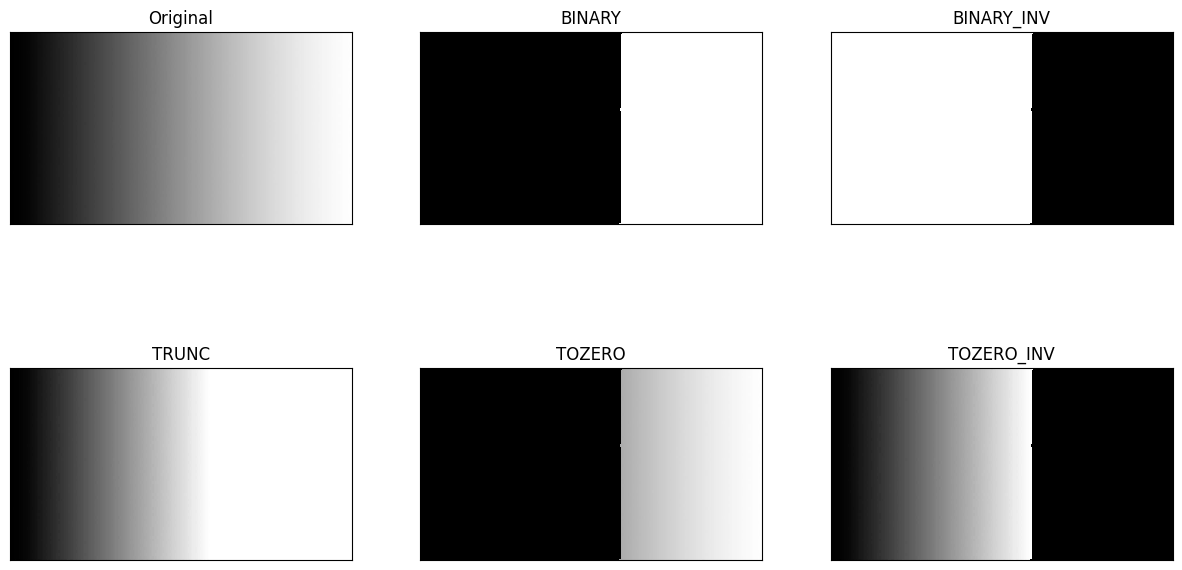

In [2]:
# 1. Load citra
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Images/gradient.jpg', 0)

# 2. Tentukan nilai threshold
T = 170

# 3. Proses thresholding manual sesuai deskripsi
binary      = np.where(img > T, 255, 0).astype(np.uint8)
binary_inv  = np.where(img > T, 0, 255).astype(np.uint8)
trunc       = np.where(img > T, T, img).astype(np.uint8)
tozero      = np.where(img > T, img, 0).astype(np.uint8)
tozero_inv  = np.where(img > T, 0, img).astype(np.uint8)

# 4. Menampilkan hasilnya
titles = ['Original', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, binary, binary_inv, trunc, tozero, tozero_inv]

plt.figure(figsize=(15, 8))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

4. Buat Otsu Thresholding tanpa menggunakan Library. Tampilkan juga nilai threshold
saat anda gunakan Otsu’s, seperti terlihat pada gambar hasil berikut. (gunakan image
balloon.jpg agar terlihat beda antara hasil otsu’s dengan global threshold biasa)


Threshold Otsu = 172


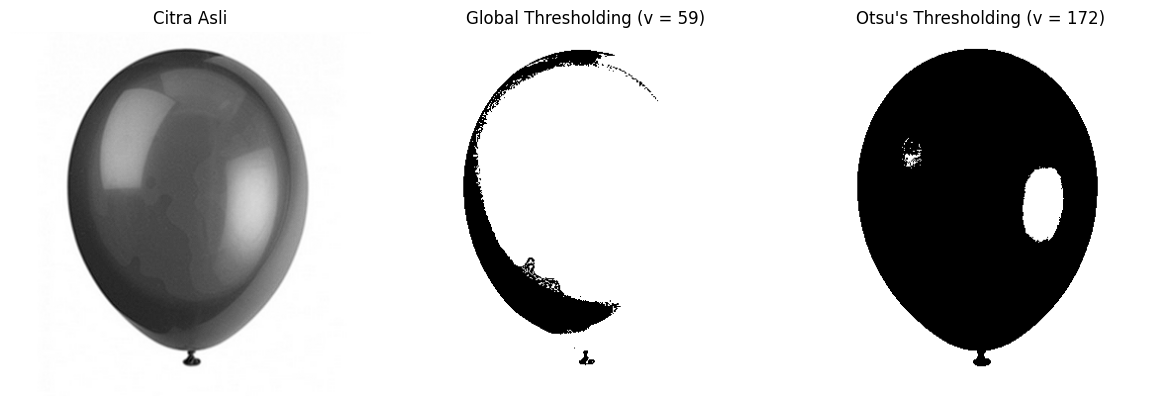

In [36]:
# Load citra grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Images/baloon.png', 0)

# Hitung histogram dan probabilitas
hist = cv.calcHist([img], [0], None, [256], [0,256]).flatten()
total = img.size
bins = np.arange(256)
p = hist / total

# Hitung nilai kumulatif
omega = np.cumsum(p)
mu = np.cumsum(p * bins)
mu_total = mu[-1]

# Variansi antar-kelas dan dalam-kelas
within_var = np.zeros(256)
between_var = np.zeros(256)

for t in range(256):
    w0 = omega[t]
    w1 = 1.0 - w0
    if w0 <= 0 or w1 <= 0:
        continue
    mu0 = mu[t] / w0
    mu1 = (mu_total - mu[t]) / w1
    between_var[t] = w0 * w1 * (mu0 - mu1)**2

# Threshold Otsu
t_otsu = np.argmax(between_var)
print("Threshold Otsu =", t_otsu)

# Threshold global (manual)
t_global = 59
_, th_global = cv.threshold(img, t_global, 255, cv.THRESH_BINARY)
_, th_otsu = cv.threshold(img, t_otsu, 255, cv.THRESH_BINARY)

# Tampilkan hasil
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(th_global, cmap='gray')
plt.title(f'Global Thresholding (v = {t_global})')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(th_otsu, cmap='gray')
plt.title(f"Otsu's Thresholding (v = {t_otsu})")
plt.axis('off')

plt.tight_layout()
plt.show()


5. Buat histogram dari citra tersegmentasi, Histogram hanya pada foreground image
saja. Gunakan image tobacco.jpg yang sudah disediakan di folder images.
Petunjuk:  
    a. anda dapat gunakan cv.calcHist untuk menampilkan histogram.

    b. Buka link berikut https://opencv
    tutorial.readthedocs.io/en/latest/histogram/histogram.html   

    c. Dari link tersebut perhatikan bahwa cv.calcHist memiliki salah satu parameter
    yaitu mask. Jika diset None, maka keseluruhan image akan dihitung
    histogramnya. Jika kita tentukan mask, maka hanya bagian image yang
    dimasking warna putih yang akan dihitung histogramnya (dari contoh dibawah dinamakan dengan Citra Segment).

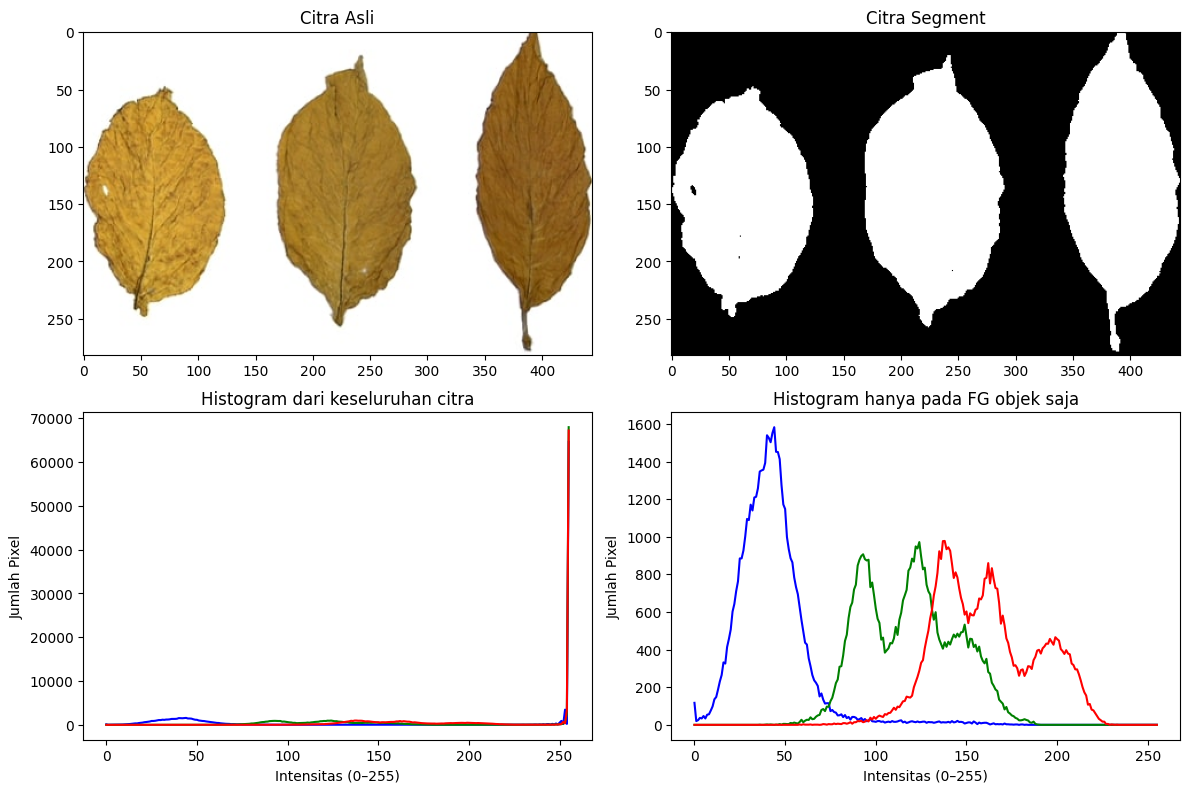

In [40]:
# Load citra
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Images/tobacco.jpg')

# Konversi ke grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Segmentasi dengan Otsu Thresholding
_, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Balik mask agar foreground (daun) = putih, background = hitam
mask = cv.bitwise_not(mask)

# Histogram seluruh citra (tiap channel BGR)
colors = ('b', 'g', 'r')
hist_all = [cv.calcHist([img], [i], None, [256], [0, 256]) for i in range(3)]

# Histogram hanya untuk foreground
hist_fg = [cv.calcHist([img], [i], mask, [256], [0, 256]) for i in range(3)]

# Visualisasi hasil
plt.figure(figsize=(12,8))

# 1. Citra Asli
plt.subplot(2,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')

# 2. Citra Segment (foreground putih)
plt.subplot(2,2,2)
plt.imshow(mask, cmap='gray')
plt.title('Citra Segment')

# 3. Histogram keseluruhan citra
plt.subplot(2,2,3)
for i, col in enumerate(colors):
    plt.plot(hist_all[i], color=col)
plt.title('Histogram dari keseluruhan citra')
plt.xlabel('Intensitas (0–255)')
plt.ylabel('Jumlah Pixel')

# 4. Histogram foreground (mask putih saja)
plt.subplot(2,2,4)
for i, col in enumerate(colors):
    plt.plot(hist_fg[i], color=col)
plt.title('Histogram hanya pada FG objek saja')
plt.xlabel('Intensitas (0–255)')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

6. Lakukan segmentasi warna pada image "peppers.jpg", munculkan hanya warna yang
kuning saja. (Petunjuk: anda dapat gunakan K-Means untuk menampilkan hanya
warna tertentu saja)

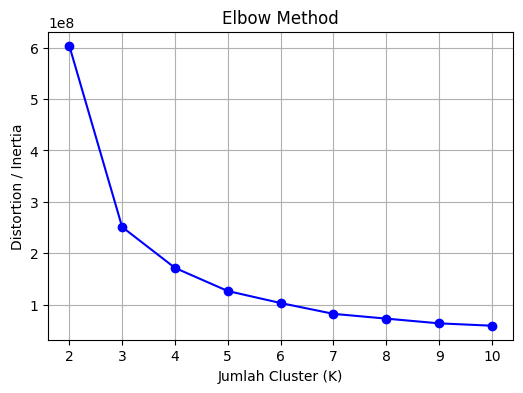

In [45]:
# Load citra
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Images/peppers.jpg')

# Konversi ke ruang warna LAB
img_lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
Z = img_lab.reshape((-1, 3))
Z = np.float32(Z)

# Elbow Method untuk menentukan jumlah cluster optimal
distortions = []
K_values = range(2, 11)
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

for k in K_values:
    _, _, centers = cv.kmeans(Z, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
    # hitung jarak total antar piksel ke cluster terdekat (distorsi)
    compactness, _, _ = cv.kmeans(Z, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
    distortions.append(compactness)

# Visualisasi Elbow Method
plt.figure(figsize=(6,4))
plt.plot(K_values, distortions, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Distortion / Inertia')
plt.grid(True)
plt.show()

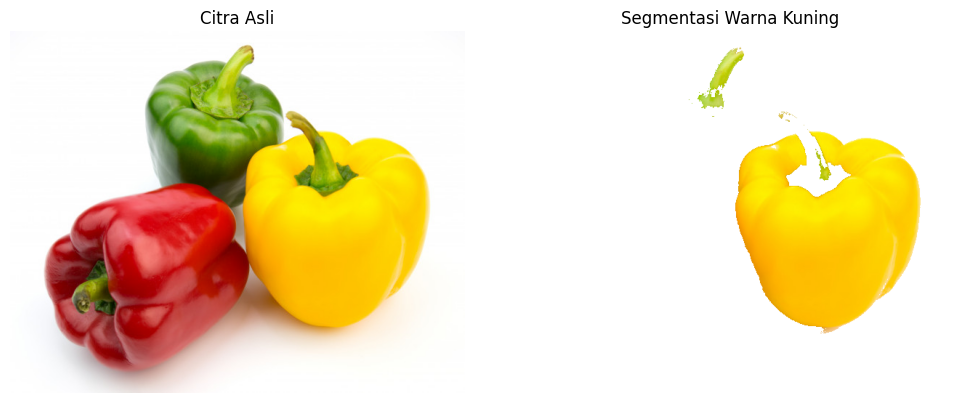

In [49]:
# K-Means clustering
K = 6
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Identifikasi cluster warna kuning
centers = np.uint8(centers)
yellow_cluster = np.argmax(centers[:, 2])  # channel b tinggi → kuning

# Buat mask untuk warna kuning
mask = (labels.flatten() == yellow_cluster).astype(np.uint8)
mask = mask.reshape((img.shape[0], img.shape[1])) * 255

# Buat background putih dan gabungkan hasil
white_bg = np.ones_like(img, dtype=np.uint8) * 255
result = white_bg.copy()
result[mask == 255] = img[mask == 255]

# Visualisasi hasil
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title('Segmentasi Warna Kuning')
plt.axis('off')

plt.tight_layout()
plt.show()

Saat anda menampilkan warna tertentu, jelaskan kendala yang di hadapi dan mengapa hal itu terjadi.

Jawab:

Segmentasi warna dengan metode K-Means sering menghadapi sejumlah tantangan. Salah satunya adalah pencahayaan yang tidak merata, sehingga intensitas cahaya berbeda-beda dan membuat warna yang seharusnya sama tampak memiliki nilai berbeda. Selain itu, adanya refleksi dan bayangan pada objek terutama pada permukaan yang mengkilap dapat menyebabkan sebagian piksel terlihat lebih terang atau lebih gelap dibandingkan warna aslinya.

7. Buka File crossword.jpg. Dengan pengetahuan tentang thresholding yang sudah anda
pelajari. Lakukan thresholding biner dengan hasil terbaik menurut anda. Copas code
dan hasil image di modul ini.

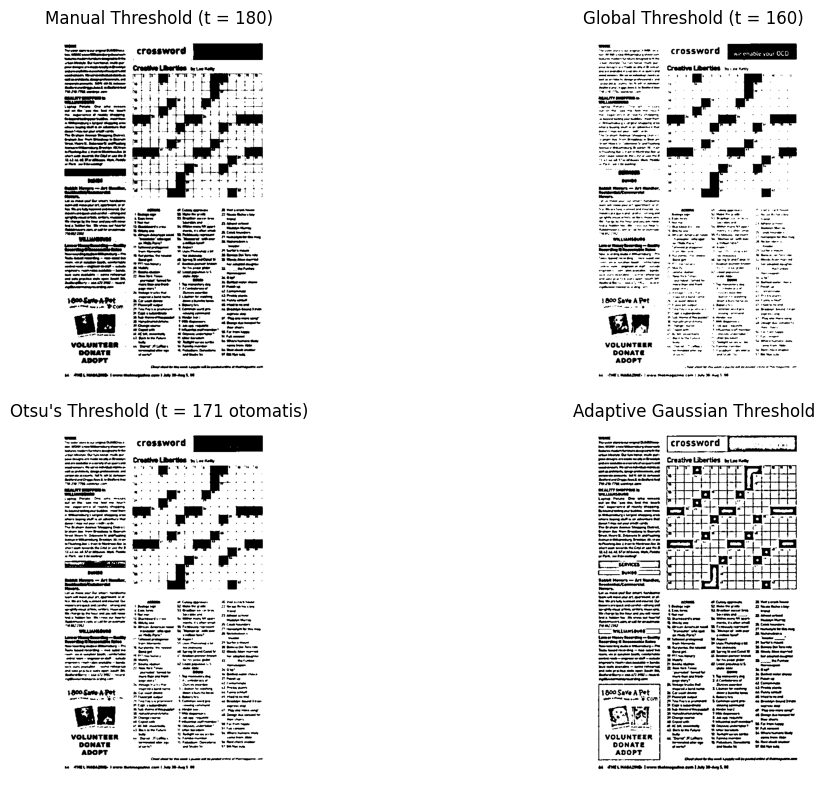

In [57]:
# Load citra grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Images/crossword.jpg', cv.IMREAD_GRAYSCALE)

# Gaussian blur untuk meredam noise
blur = cv.GaussianBlur(img, (5, 5), 0)

# Manual Threshold
t_manual = 180
_, th_manual = cv.threshold(blur, t_manual, 255, cv.THRESH_BINARY)

# GLobal Threshold
t_global = 160
_, th_global = cv.threshold(blur, t_global, 255, cv.THRESH_BINARY)

# Thresholding Otsu
_, th_otsu = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Thresholding adaptif
th_adapt = cv.adaptiveThreshold(blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv.THRESH_BINARY, 25, 10)

# Visualisasi hasil
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
plt.imshow(th_manual, cmap='gray')
plt.title(f'Manual Threshold (t = {t_manual})')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(th_global, cmap='gray')
plt.title(f'Global Threshold (t = {t_global})')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(th_otsu, cmap='gray')
plt.title(f"Otsu's Threshold (t = {int(_)} otomatis)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(th_adapt, cmap='gray')
plt.title('Adaptive Gaussian Threshold')
plt.axis('off')

plt.tight_layout()
plt.show()